In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

In [3]:
adata = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_celloracle_compatible_v2.h5ad')

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
adata

AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

In [5]:
adata.obs['C_scANVI'].value_counts()

C_scANVI
Fast IIX         34128
Fast IIB         33378
MTJ               5034
EC                3263
FAPs              2830
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
NMJ               1066
Macrophages        968
Name: count, dtype: int64

### Re-annotate the cell-populations to separate out the type2a population

In [6]:
adata_full = adata.raw.to_adata()
adata_full.obs = adata.obs.copy()
adata_full.obs_names_make_unique()

# Look at the actual non-zero values, not the top-left corner
import numpy as np
from scipy import sparse
X = adata_full.X
nz = X.data[:10000] if sparse.issparse(X) else X[X != 0][:10000]
print("non-zero sample:", nz[:20])
print("min / max / mean:", nz.min(), nz.max(), nz.mean())

is_counts = np.allclose(nz, nz.astype(int))
print(f"raw.X looks like {'counts' if is_counts else 'log-normalized'}")

if is_counts:
    sc.pp.normalize_total(adata_full, target_sum=1e4)
    sc.pp.log1p(adata_full)

non-zero sample: [1.20294712 1.20294712 1.73339425 1.73339425 2.70668238 1.20294712
 1.20294712 2.97753414 2.85125045 2.85125045 1.73339425 1.20294712
 3.08964353 2.07815927 2.70668238 1.20294712 1.20294712 1.20294712
 2.33405125 1.20294712]
min / max / mean: 1.0257651570429829 7.200938873661968 1.6548693688666176
raw.X looks like log-normalized


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
import pandas as pd

# Pool of cells eligible for fiber-type reassignment
fast_pool = adata.obs["C_scANVI"].isin(["Fast IIX", "Fast IIB", "MTJ"])

# Myosin expression from the full-gene object
expr = sc.get.obs_df(adata_full, ["Myh2", "Myh1", "Myh4", "Myh7"])
expr.index = adata.obs_names

detected = (expr.max(axis=1) > 0.5) & fast_pool
winner = expr.idxmax(axis=1)
label_map = {"Myh2": "IIA", "Myh1": "IIX", "Myh4": "IIB", "Myh7": "I"}

# Start from the original annotation
re_annot = adata.obs["C_scANVI"].astype(str).copy()

# Fast IIX / Fast IIB cells: flatten to their dominant-myosin fiber type
fast_only = detected & adata.obs["C_scANVI"].isin(["Fast IIX", "Fast IIB"])
re_annot.loc[fast_only] = winner[fast_only].map(label_map).map(
    {"IIA": "Fast IIA", "IIX": "Fast IIX", "IIB": "Fast IIB", "I": "Fast I"}
).values

# MTJ cells: keep MTJ identity, append fiber-type subtype
mtj_call = detected & (adata.obs["C_scANVI"] == "MTJ")
re_annot.loc[mtj_call] = ("MTJ-" + winner[mtj_call].map(label_map)).values

adata.obs["re_annot"] = pd.Categorical(re_annot)
print(adata.obs["re_annot"].value_counts())
print(pd.crosstab(adata.obs["C_scANVI"], adata.obs["re_annot"]))

re_annot
Fast IIB         42262
Fast IIX         21819
Fast IIA          3414
EC                3263
FAPs              2830
MTJ-IIB           2736
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
MTJ-IIX           1767
NMJ               1066
Macrophages        968
MTJ-IIA            511
MTJ                 17
Fast I              11
MTJ-I                3
Name: count, dtype: int64
re_annot         EC  FAPs  Fast I  Fast IIA  Fast IIB  Fast IIX  MTJ  MTJ-I  \
C_scANVI                                                                      
EC             3263     0       0         0         0         0    0      0   
FAPs              0  2830       0         0         0         0    0      0   
Fast IIB          0     0       0        26     32845       507    0      0   
Fast IIX          0     0      11      3388      9417     21312    0      0   
MTJ               0     0       0         0         0         0   17      3   
Macrophages       0     0       0         0 

In [8]:
# Drop cells in any re_annot category with fewer than 50 members
min_cells = 50
keep_cats = adata.obs["re_annot"].value_counts()
keep_cats = keep_cats[keep_cats >= min_cells].index.tolist()

adata_re = adata[adata.obs["re_annot"].isin(keep_cats)].copy()
adata_re.obs["re_annot"] = (
    adata_re.obs["re_annot"].cat.remove_unused_categories()
)

print(f"dropped {adata.n_obs - adata_re.n_obs} cells "
      f"from {len(adata.obs['re_annot'].cat.categories) - len(keep_cats)} categories")
print(adata_re.obs["re_annot"].value_counts())

dropped 31 cells from 3 categories
re_annot
Fast IIB         42262
Fast IIX         21819
Fast IIA          3414
EC                3263
FAPs              2830
MTJ-IIB           2736
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
MTJ-IIX           1767
NMJ               1066
Macrophages        968
MTJ-IIA            511
Name: count, dtype: int64


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
re_annot_palette = {
    "Fast IIA":      "#1B5E20",
    "Fast IIB":      "#4A148C",
    "Fast IIX":      "#FFAB91",
    "MTJ-IIA":       "#A5D6A7",
    "MTJ-IIB":       "#B39DDB",
    "MTJ-IIX":       "#EFE0C5",
    "EC":            "#E53935",
    "FAPs":          "#1E88E5",
    "Pericyte":      "#D2B48C",
    "Tendon":        "#6D4C41",
    "Skeleton MuSc": "#00897B",
    "NMJ":           "#FDD835",
    "Macrophages":   "#F57C00",
}

# C_scANVI shares most names with re_annot, but has the unsplit "MTJ" instead
# of MTJ-IIA/IIB/IIX. Pick an MTJ color that doesn't clash with anything else —
# medium purple sits between the IIA and stromal palettes.
c_scanvi_palette = {**re_annot_palette, "MTJ": "#7E57C2"}

# Make sure both columns are clean Categoricals
for col, pal in [("re_annot", re_annot_palette), ("C_scANVI", c_scanvi_palette)]:
    adata_re.obs[col] = adata_re.obs[col].astype(str).astype("category")
    cats = [c for c in adata_re.obs[col].cat.categories if c in pal]
    # Drop any cells in non-palette categories (shouldn't be any after filtering)
    adata_re = adata_re[adata_re.obs[col].isin(cats)].copy()
    adata_re.obs[col] = adata_re.obs[col].astype(str).astype("category")
    counts = adata_re.obs[col].value_counts().sort_values(ascending=False)
    adata_re.obs[col] = adata_re.obs[col].cat.reorder_categories(counts.index.tolist())
    adata_re.uns[f"{col}_colors"] = [pal[c] for c in adata_re.obs[col].cat.categories]


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


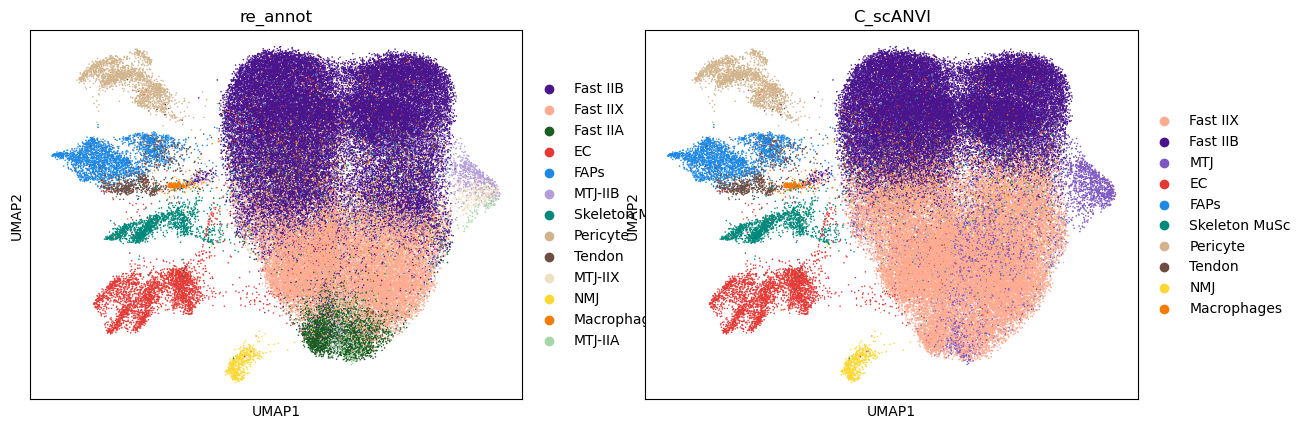

In [25]:
fig = sc.pl.umap(
    adata_re,
    color=["re_annot", "C_scANVI"],
    ncols=2, vmax="p99", size=5,
    return_fig=True,
)
fig.savefig(f"{figures_dir}/umap_reannot.svg", bbox_inches="tight", format="svg")
plt.show()

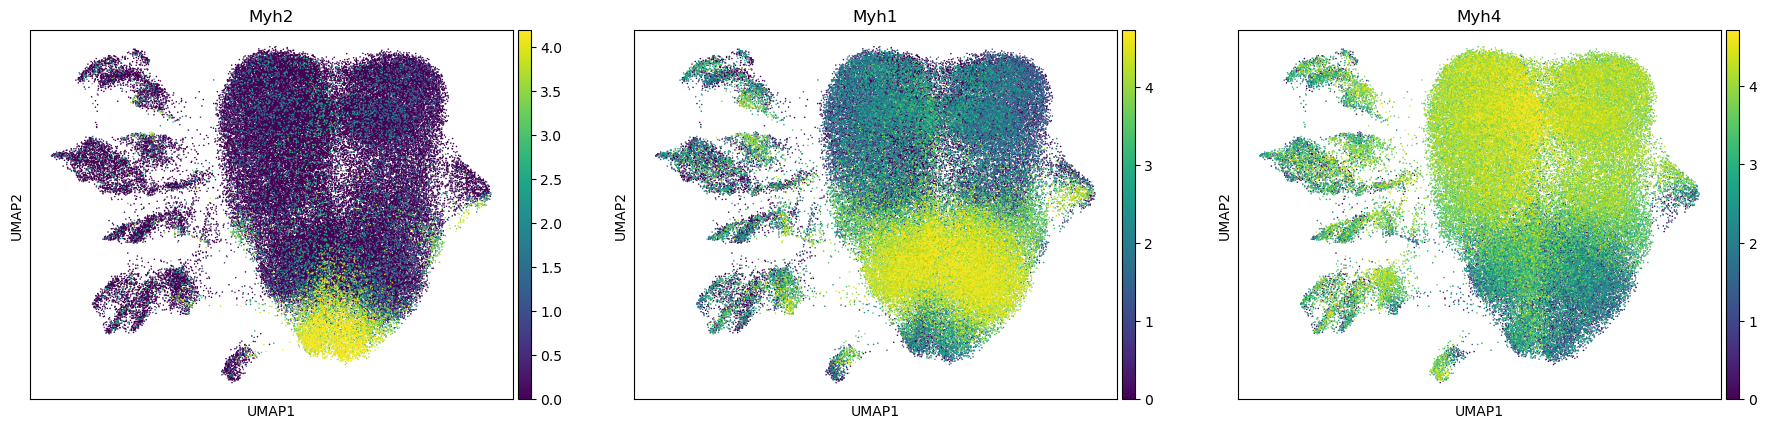

In [26]:
fig = sc.pl.umap(
    adata_re,
    color=["Myh2", "Myh1", "Myh4"],
    ncols=3, vmax="p99", size=5,
    return_fig=True,
)
fig.savefig(f"{figures_dir}/umap_markers.svg", bbox_inches="tight", format="svg")
plt.show()

In [ ]:
adata_type2 = adata_re[adata_re.obs['re_annot'].isin(['Fast IIB', 'Fast IIA', 'Fast IIX'])]
fig = sc.pl.umap(
    adata_type2,
    color=["re_annot", "sex", "condition"],
    ncols=2, vmax="p99", size=5,
    return_fig=True,
)
fig.savefig(f"{figures_dir}/umap_reannot.svg", bbox_inches="tight", format="svg")
plt.show()

In [ ]:
# write the adata oobject 
adata_re.write_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/re_annot.h5ad')

# Marker gene dotplot

Marker panel:
  Fiber call (myosins): ['Myh2', 'Myh1', 'Myh4']
  Pan-fast: ['Tnnt3', 'Tnnc2']
  Fast IIA: ['Atp2a1', 'Lpl']
  MTJ: ['Col22a1', 'Ankrd1', 'Csrp3']
  Skeleton MuSc: ['Pax7', 'Cd34']
  FAPs: ['Pdgfra', 'Dcn', 'Col1a1']
  EC: ['Pecam1', 'Cdh5', 'Kdr']
  Pericyte: ['Rgs5', 'Kcnj8', 'Notch3']
  Tendon: ['Scx', 'Tnmd', 'Mkx']
  NMJ: ['Chrne', 'Chrna1', 'Musk', 'Lrp4']
  Macrophages: ['Cd68', 'Adgre1', 'Csf1r', 'Lyz2']


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


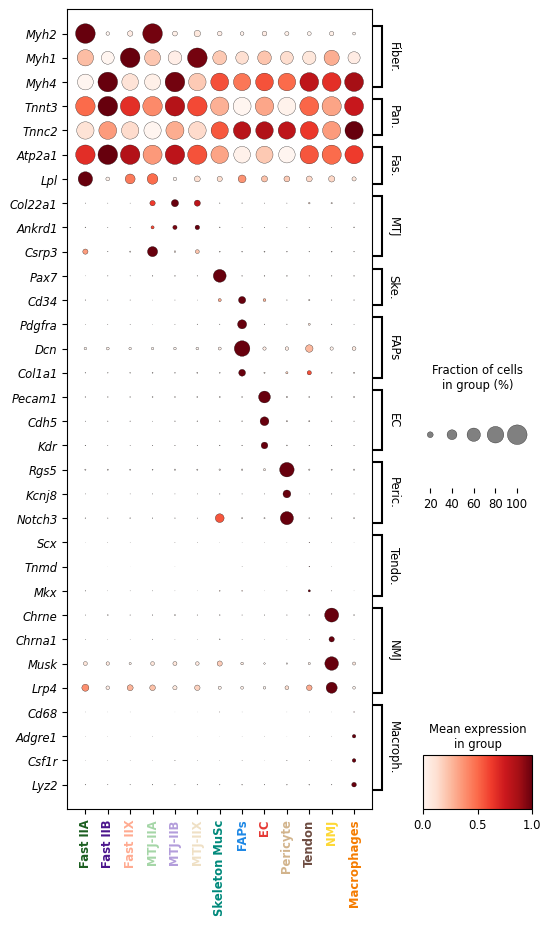

In [33]:
import matplotlib.pyplot as plt

# --- Build dotplot-ready object: full genes + filtered cells with re_annot ---
adata_full.obs["re_annot"] = adata.obs["re_annot"].values
adata_full.obs["re_annot"] = adata_full.obs["re_annot"].astype("category")

keep_cats = list(adata_re.obs["re_annot"].cat.categories)
ad_dot = adata_full[adata_full.obs["re_annot"].isin(keep_cats)].copy()
ad_dot.obs["re_annot"] = ad_dot.obs["re_annot"].cat.remove_unused_categories()

# Apply the same category ordering as adata_re for consistency across plots
cat_order = ["Fast IIA", "Fast IIB", "Fast IIX",
             "MTJ-IIA", "MTJ-IIB", "MTJ-IIX",
             "Skeleton MuSc", "FAPs", "EC", "Pericyte",
             "Tendon", "NMJ", "Macrophages"]
cat_order = [c for c in cat_order if c in ad_dot.obs["re_annot"].cat.categories]
ad_dot.obs["re_annot"] = ad_dot.obs["re_annot"].cat.reorder_categories(cat_order)

# --- Canonical TA / snRNA-seq marker panel (Pathak / Aditi reference) ---
# The four myosins encode the dominant-myosin reassignment logic:
#   Myh2 → IIA, Myh1 → IIX, Myh4 → IIB, Myh7 → I
markers = {
    "Fiber call (myosins)": ["Myh2", "Myh1", "Myh4"],
    "Pan-fast":             ["Tnnt3", "Tnnc2"],
    "Fast IIA":             ["Atp2a1", "Lpl"],
    "MTJ":                  ["Col22a1", "Ankrd1", "Csrp3"],
    "Skeleton MuSc":        ["Pax7", "Cd34"],
    "FAPs":                 ["Pdgfra", "Dcn", "Col1a1"],
    "EC":                   ["Pecam1", "Cdh5", "Kdr"],
    "Pericyte":             ["Rgs5", "Kcnj8", "Notch3"],
    "Tendon":               ["Scx", "Tnmd", "Mkx"],
    "NMJ":                  ["Chrne", "Chrna1", "Musk", "Lrp4"],
    "Macrophages":          ["Cd68", "Adgre1", "Csf1r", "Lyz2"],
}
markers = {k: [g for g in v if g in ad_dot.var_names] for k, v in markers.items()}
markers = {k: v for k, v in markers.items() if v}
print("Marker panel:")
for k, v in markers.items():
    print(f"  {k}: {v}")

# --- Dotplot ---
dp = sc.pl.dotplot(
    ad_dot,
    var_names=markers,
    groupby="re_annot",
    standard_scale="var",
    cmap="Reds",
    swap_axes=True,
    var_group_rotation=0,
    figsize=(6, 10),
    return_fig=True,
)
dp.make_figure()

# --- Color cell-type tick labels using the re_annot palette ---
ax = dp.ax_dict["mainplot_ax"]
for label in ax.get_xticklabels():
    txt = label.get_text()
    if txt in re_annot_palette:
        label.set_color(re_annot_palette[txt])
        label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontstyle("italic")

plt.savefig(f"{figures_dir}/dotplot_re_annot_markers.png", dpi=300, bbox_inches="tight")
plt.show()

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


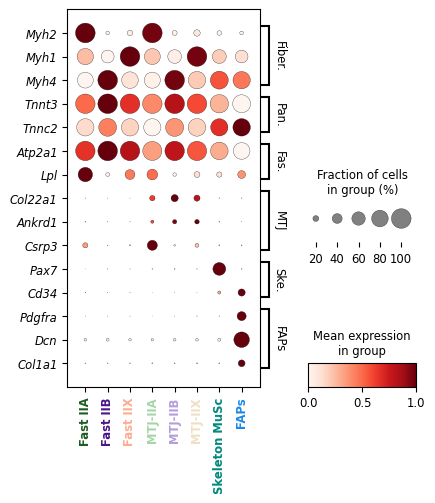

In [29]:
import matplotlib.pyplot as plt

# Cell types to include in the focused dotplot
focus_cats = ["Fast IIA", "Fast IIB", "Fast IIX",
              "MTJ-IIA", "MTJ-IIB", "MTJ-IIX",
              "Skeleton MuSc", "FAPs"]

ad_dot_small = ad_dot[ad_dot.obs["re_annot"].isin(focus_cats)].copy()
ad_dot_small.obs["re_annot"] = (
    ad_dot_small.obs["re_annot"].cat.remove_unused_categories()
                                    .cat.reorder_categories(focus_cats)
)

# Trimmed marker panel — drop groups for cell types not in the plot
markers_small = {
    "Fiber call (myosins)": ["Myh2", "Myh1", "Myh4"],
    "Pan-fast":             ["Tnnt3", "Tnnc2"],
    "Fast IIA":             ["Atp2a1", "Lpl"],
    "MTJ":                  ["Col22a1", "Ankrd1", "Csrp3"],
    "Skeleton MuSc":        ["Pax7", "Cd34"],
    "FAPs":                 ["Pdgfra", "Dcn", "Col1a1"],
}
markers_small = {k: [g for g in v if g in ad_dot_small.var_names]
                 for k, v in markers_small.items()}
markers_small = {k: v for k, v in markers_small.items() if v}

dp = sc.pl.dotplot(
    ad_dot_small,
    var_names=markers_small,
    groupby="re_annot",
    standard_scale="var",
    cmap="Reds",
    swap_axes=True,
    var_group_rotation=0,
    figsize=(4.5, 4.5),
    return_fig=True,
)
dp.make_figure()

ax = dp.ax_dict["mainplot_ax"]
for label in ax.get_xticklabels():
    txt = label.get_text()
    if txt in re_annot_palette:
        label.set_color(re_annot_palette[txt])
        label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontstyle("italic")

plt.savefig(f"{figures_dir}/dotplot_myofiber_type2.svg", dpi=300, bbox_inches="tight")
plt.show()